# Sprint 8 - Análise de Negócio
# Projeto: Otimização de Investimentos de Marketing - Y.Afisha

## **Introdução / Apresentação do Projeto**

### **Contexto do Negócio**
A Y.Afisha é um serviço de entretenimento que busca otimizar suas despesas com publicidade. Como analista de dados, o objetivo deste projeto é processar dados brutos de acessos, pedidos e custos para responder a perguntas fundamentais de crescimento (Growth):

- 1. Produto: Como os usuários interagem com a plataforma e qual a taxa de retenção?
- 2. Vendas: Qual o tempo médio de conversão e o valor gerado por cada cliente (LTV)?
- 3. Marketing: Quais origens de anúncio são rentáveis e quais apresentam um custo de aquisição (CAC) inviável?

### **Objetivos Técnicos**
- 1. Realizar a limpeza e otimização dos tipos de dados para análise temporal.
- 2. Calcular métricas de audiência: DAU, WAU, MAU e duração média das sessões.
- 3. Realizar análise de Coortes para identificar o Lifetime Value (LTV).
- 4. Avaliar o Retorno sobre Investimento (ROMI) por canal e dispositivo.
- 5. Recomendar a redistribuição estratégica do orçamento de marketing.

## ✅ FASE 1 - Carregamento e Preparação dos Dados


### 1.1 Importação e Extração dos DataFrames

In [ ]:
# Importando Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [ ]:
# Carregando os dados do projeto
df_visits = pd.read_csv('/datasets/visits_log_us.csv')
df_orders = pd.read_csv('/datasets/orders_log_us.csv')
df_costs = pd.read_csv('/datasets/costs_us.csv')
print("✅ Arquivos carregados com sucesso!")

✅ Arquivos carregados com sucesso!


### 1.2 - Visualização Inicial do DataFrame df_visits

In [ ]:
# === VISUALIZAÇÃO INICIAL DOS DADOS ===
print("=" * 80)
print("VISUALIZAÇÃO COMPLETA DO DATAFRAME df_visits")
print("=" * 80)

# 1. Dimensões do DataFrame
print(f"\n📊 Dimensões: {df_visits.shape[0]} linhas e {df_visits.shape[1]} colunas")

# 2. Informações das colunas (nome e tipo)
print("\n📋 Estrutura das colunas:")
print("-" * 50)
for col in df_visits.columns:
    print(f"   • {col:<30} → {df_visits[col].dtype}")

# 3. Visualização das 5 primeiras linhas
print("\n🔍 Primeiras 5 linhas do DataFrame:")
print("-" * 80)
print(df_visits.head())

# 4. Informações estatísticas básicas (opcional)
print("\n📈 Estatísticas descritivas das colunas numéricas:")
print("-" * 80)
print(df_visits.describe())


# 5. Verificação de valores nulos (opcional)
print("\n⚠️ Valores ausentes por coluna:")
print("-" * 80)
print(df_visits.isnull().sum())
print("✅ Arquivos carregados com sucesso!")

VISUALIZAÇÃO COMPLETA DO DATAFRAME df_visits

📊 Dimensões: 359400 linhas e 5 colunas

📋 Estrutura das colunas:
--------------------------------------------------
   • Device                         → object
   • End Ts                         → object
   • Source Id                      → int64
   • Start Ts                       → object
   • Uid                            → uint64

🔍 Primeiras 5 linhas do DataFrame:
--------------------------------------------------------------------------------
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   745903560337

### 1.3 - Visualização Inicial do DataFrame df_orders

In [ ]:
# === VISUALIZAÇÃO INICIAL DOS DADOS ===
print("=" * 80)
print("VISUALIZAÇÃO COMPLETA DO DATAFRAME df_orders")
print("=" * 80)

# 1. Dimensões do DataFrame
print(f"\n📊 Dimensões: {df_orders.shape[0]} linhas e {df_orders.shape[1]} colunas")

# 2. Informações das colunas (nome e tipo)
print("\n📋 Estrutura das colunas:")
print("-" * 50)
for col in df_orders.columns:
    print(f"   • {col:<30} → {df_orders[col].dtype}")

# 3. Visualização das 5 primeiras linhas
print("\n🔍 Primeiras 5 linhas do DataFrame:")
print("-" * 80)
print(df_orders.head())

# 4. Informações estatísticas básicas (opcional)
print("\n📈 Estatísticas descritivas das colunas numéricas:")
print("-" * 80)
print(df_orders.describe())


# 5. Verificação de valores nulos (opcional)
print("\n⚠️ Valores ausentes por coluna:")
print("-" * 80)
print(df_orders.isnull().sum())
print("✅ Arquivos carregados com sucesso!")

VISUALIZAÇÃO COMPLETA DO DATAFRAME df_orders

📊 Dimensões: 50415 linhas e 3 colunas

📋 Estrutura das colunas:
--------------------------------------------------
   • Buy Ts                         → object
   • Revenue                        → float64
   • Uid                            → uint64

🔍 Primeiras 5 linhas do DataFrame:
--------------------------------------------------------------------------------
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450

📈 Estatísticas descritivas das colunas numéricas:
--------------------------------------------------------------------------------
            Revenue           Uid
count  50415.000000  5.041500e+04
mean       4.999647  9.098161e+18
std       21.818359  5.28574

### 1.4 - Visualização Inicial do DataFrame df_costs

In [ ]:
# === VISUALIZAÇÃO INICIAL DOS DADOS ===
print("=" * 80)
print("VISUALIZAÇÃO COMPLETA DO DATAFRAME df_costs")
print("=" * 80)

# 1. Dimensões do DataFrame
print(f"\n📊 Dimensões: {df_costs.shape[0]} linhas e {df_costs.shape[1]} colunas")

# 2. Informações das colunas (nome e tipo)
print("\n📋 Estrutura das colunas:")
print("-" * 50)
for col in df_costs.columns:
    print(f"   • {col:<30} → {df_costs[col].dtype}")

# 3. Visualização das 5 primeiras linhas
print("\n🔍 Primeiras 5 linhas do DataFrame:")
print("-" * 80)
print(df_costs.head())

# 4. Informações estatísticas básicas (opcional)
print("\n📈 Estatísticas descritivas das colunas numéricas:")
print("-" * 80)
print(df_costs.describe())


# 5. Verificação de valores nulos (opcional)
print("\n⚠️ Valores ausentes por coluna:")
print("-" * 80)
print(df_costs.isnull().sum())
print("✅ Arquivos carregados com sucesso!")

VISUALIZAÇÃO COMPLETA DO DATAFRAME df_costs

📊 Dimensões: 2542 linhas e 3 colunas

📋 Estrutura das colunas:
--------------------------------------------------
   • source_id                      → int64
   • dt                             → object
   • costs                          → float64

🔍 Primeiras 5 linhas do DataFrame:
--------------------------------------------------------------------------------
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08

📈 Estatísticas descritivas das colunas numéricas:
--------------------------------------------------------------------------------
         source_id        costs
count  2542.000000  2542.000000
mean      4.857199   129.477427
std       3.181581   156.296628
min       1.000000     0.540000
25%       2.000000    21.945000
50%       4.000000    77.295000
75%       9.000000   170.065000
max      

### 1.5 - Conversão de tipos de dados

In [ ]:
# Convertendo colunas do tipo object em datetime
# Convertendo nomes das colunas para minúsculo

# Para o DataFrame 'df_visits'
df_visits['Start Ts'] = df_visits['Start Ts'].astype('datetime64[ns]')
df_visits['End Ts'] = df_visits['End Ts'].astype('datetime64[ns]')
df_visits['Uid'] = df_visits['Uid'].astype('int64')
df_visits.columns = df_visits.columns.str.lower().str.replace(' ', '_')

# Para o DataFrame 'df_orders'
df_orders['Buy Ts'] = df_orders['Buy Ts'].astype('datetime64[ns]')
df_orders['Uid'] = df_orders['Uid'].astype('int64')
df_orders.columns = df_orders.columns.str.lower().str.replace(' ', '_')

# Para o DataFrame 'df_costs'
df_costs['dt'] = df_costs['dt'].astype('datetime64[ns]')
df_costs.columns = df_costs.columns.str.lower().str.replace(' ', '_')
print("✅ Arquivos carregados com sucesso!")

✅ Arquivos carregados com sucesso!


In [ ]:
# Visualizando as correções
print('='*30)
print('DataFrame df_visits')
print('='*30)
print(df_visits.info())

print('='*30)
print('DataFrame df_orders')
print('='*30)
print(df_orders.info())

print('='*30)
print('DataFrame df_costs')
print('='*30)
print(df_costs.info())

DataFrame df_visits
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  int64         
dtypes: datetime64[ns](2), int64(2), object(1)
memory usage: 13.7+ MB
None
DataFrame df_orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.2 MB
None
DataFrame df_costs
<class 'panda

### 1.6 - Conclusões
- Nesta fase, os dados foram carregados e validados. Realizamos a conversão das colunas de data (object) para o formato , permitindo cálculos temporais precisos. Além disso, os nomes das colunas foram normalizados para letras minúsculas e os identificadores de usuário (Uid) foram tratados como inteiros. Não foram identificados valores ausentes críticos, o que garante a integridade das análises subsequentes.

## 📦 FASE 2 - Análise do Produto (Comportamento dos Usuários)
### Objetivo: Entender como as pessoas usam o produto
**O que fazer:** Contar quantos usuários únicos acessam o produto por dia, semana e mês.

### 2.1 - Criando colunas para o DataFrame df_visits

In [ ]:
# Criando colunas day, month and year
df_visits['date'] = df_visits['start_ts'].dt.date
df_visits['week'] = df_visits['start_ts'].dt.week
df_visits['month'] = df_visits['start_ts'].dt.month
df_visits['year'] = df_visits['start_ts'].dt.year

### 2.2 - Quantas pessoas usam por dia, semana e mês?

In [ ]:
# Calculando DAU (Daily Active Users) - usuários únicos por dia
dau = df_visits.groupby('date')['uid'].nunique()

# Calculando WAU (Weekly Active Users) - usuários únicos por semana
wau = df_visits.groupby(['year', 'week'])['uid'].nunique()

# Calculando MAU (Monthly Active Users) - usuários únicos por mês
mau = df_visits.groupby(['year', 'month'])['uid'].nunique()

# Exibindo resultados
print("=" * 50)
print("MÉTRICAS DE USUÁRIOS ATIVOS")
print("=" * 50)
print(f"DAU médio: {dau.mean():.0f} usuários/dia")
print(f"WAU médio: {wau.mean():.0f} usuários/semana")
print(f"MAU médio: {mau.mean():.0f} usuários/mês")
print("=" * 50)

MÉTRICAS DE USUÁRIOS ATIVOS
DAU médio: 908 usuários/dia
WAU médio: 5716 usuários/semana
MAU médio: 23228 usuários/mês


### 2.3 - Quantas sessões ocorrem por dia?

In [ ]:
# Contando total de sessões por dia (cada linha é uma sessão)
sessoes_por_dia = df_visits.groupby('date').size()

# Calculando média de sessões por usuário por dia
sessoes_por_usuario_dia = df_visits.groupby(['date', 'uid']).size().groupby('date').mean()

# Exibindo resultados
print("=" * 50)
print("MÉTRICAS DE SESSÕES")
print("=" * 50)
print(f"Média de sessões por dia: {sessoes_por_dia.mean():.1f}")
print(f"Média de sessões por usuário por dia: {sessoes_por_usuario_dia.mean():.2f}")
print(f"Dia com maior número de sessões: {sessoes_por_dia.max()}")
print("=" * 50)

MÉTRICAS DE SESSÕES
Média de sessões por dia: 987.4
Média de sessões por usuário por dia: 1.08
Dia com maior número de sessões: 4042


### 2.4 - Qual o comprimento de cada sessão?

In [ ]:
# Calculando duração em minutos
df_visits['duracao_min'] = (df_visits['end_ts'] - df_visits['start_ts']).dt.total_seconds() / 60

# Removendo dados inconsistentes (duração negativa)
df_visits_clean = df_visits[df_visits['duracao_min'] > 0]

# Removendo outliers (sessões com mais de 24 horas)
df_visits_clean = df_visits_clean[df_visits_clean['duracao_min'] <= 1440]

# Exibindo resultados
print("=" * 50)
print("DURAÇÃO DAS SESSÕES (em minutos)")
print("=" * 50)
print(f"Média: {df_visits_clean['duracao_min'].mean():.2f} min")
print(f"Mediana: {df_visits_clean['duracao_min'].median():.2f} min")
print(f"Mínimo: {df_visits_clean['duracao_min'].min():.2f} min")
print(f"Máximo: {df_visits_clean['duracao_min'].max():.2f} min")
print("=" * 50)

# Duração por dispositivo
print("\nDuração média por dispositivo:")
print(df_visits_clean.groupby('device')['duracao_min'].mean())

DURAÇÃO DAS SESSÕES (em minutos)
Média: 11.90 min
Mediana: 6.00 min
Mínimo: 0.32 min
Máximo: 711.00 min

Duração média por dispositivo:
device
desktop    12.884309
touch       9.135702
Name: duracao_min, dtype: float64


### 2.5 - Com que frequência os usuários voltam?

In [ ]:
# Primeira visita de cada usuário
primeira_visita = df_visits.groupby('uid')['date'].min().reset_index()
primeira_visita.columns = ['uid', 'primeira_data']

# Juntar com os dados originais
df_retencao = df_visits.merge(primeira_visita, on='uid', how='left')

# Calcular dias após primeira visita
df_retencao['dias_apos_primeira'] = (pd.to_datetime(df_retencao['date']) -
                                      pd.to_datetime(df_retencao['primeira_data'])).dt.days

# Total de usuários
total_usuarios = primeira_visita['uid'].nunique()

# Retenção D1 (voltaram no dia seguinte)
d1_users = df_retencao[df_retencao['dias_apos_primeira'] == 1]['uid'].nunique()
retencao_d1 = (d1_users / total_usuarios) * 100

# Visitas por usuário
visitas_por_usuario = df_visits.groupby('uid').size()

# Exibir resultados
print("=" * 50)
print("FREQUÊNCIA DE RETORNO")
print("=" * 50)
print(f"Total de usuários únicos: {total_usuarios:,}")
print(f"Retenção D1: {retencao_d1:.1f}%")
print(f"Média de visitas por usuário: {visitas_por_usuario.mean():.2f}")
print(f"Usuários que voltaram pelo menos 1 vez: {(visitas_por_usuario > 1).sum():,}")
print(f"Percentual que voltou: {((visitas_por_usuario > 1).sum() / total_usuarios) * 100:.1f}%")
print("=" * 50)

FREQUÊNCIA DE RETORNO
Total de usuários únicos: 228,169
Retenção D1: 2.6%
Média de visitas por usuário: 1.58
Usuários que voltaram pelo menos 1 vez: 52,128
Percentual que voltou: 22.8%


## 2.6 - Conclusões
- A análise de comportamento revelou um DAU médio de 908 usuários. Observamos que a média de sessões por usuário é baixa (1.08 por dia), indicando que os usuários raramente acessam o site mais de uma vez diariamente. A mediana de duração das sessões é de 6 minutos, sugerindo um uso rápido e objetivo da plataforma. A taxa de retenção no dia seguinte (D1) é de 2,6%, o que aponta uma oportunidade de melhoria no engajamento para trazer os usuários de volta de forma recorrente.

## FASE 3 - Análise de Vendas

### 3.1 - Criando colunas para o df_orders

In [ ]:
# Criando colunas de data no df_orders
df_orders['date'] = df_orders['buy_ts'].dt.date
df_orders['year'] = df_orders['buy_ts'].dt.year
df_orders['month'] = df_orders['buy_ts'].dt.month
df_orders['week'] = df_orders['buy_ts'].dt.week

### 3.2 - Tempo até a primeira compra (conversão)

In [ ]:
# Primeira visita de cada usuário
primeira_visita = df_visits.groupby('uid')['start_ts'].min().reset_index()
primeira_visita.columns = ['uid', 'primeira_visita']

# Primeira compra de cada usuário
primeira_compra = df_orders.groupby('uid')['buy_ts'].min().reset_index()
primeira_compra.columns = ['uid', 'primeira_compra']

# Juntar (apenas quem comprou)
tempo_conversao = primeira_visita.merge(primeira_compra, on='uid', how='inner')

# Calcular dias para conversão
tempo_conversao['dias_conversao'] = (tempo_conversao['primeira_compra'] - tempo_conversao['primeira_visita']).dt.days

# Classificar por categoria
def categoria_conversao(dias):
    if dias == 0:
        return '0d (mesmo dia)'
    elif dias <= 7:
        return '1-7d'
    elif dias <= 30:
        return '8-30d'
    else:
        return '30d+'

tempo_conversao['categoria'] = tempo_conversao['dias_conversao'].apply(categoria_conversao)

# Exibir resultados
print("=" * 50)
print("TEMPO ATÉ A PRIMEIRA COMPRA")
print("=" * 50)
print(f"Total de clientes: {len(tempo_conversao):,}")
print(f"Média de dias para comprar: {tempo_conversao['dias_conversao'].mean():.1f} dias")
print(f"Mediana de dias para comprar: {tempo_conversao['dias_conversao'].median():.0f} dias")
print("-" * 50)
print("Distribuição por categoria:")
print(tempo_conversao['categoria'].value_counts(normalize=True) * 100)
print("=" * 50)

TEMPO ATÉ A PRIMEIRA COMPRA
Total de clientes: 36,523
Média de dias para comprar: 16.7 dias
Mediana de dias para comprar: 0 dias
--------------------------------------------------
Distribuição por categoria:
0d (mesmo dia)    72.181913
30d+              13.421679
1-7d               8.433042
8-30d              5.963366
Name: categoria, dtype: float64


### 3.3 - Quantos pedidos os clientes fazem?

In [ ]:
# Número de pedidos por cliente
# Contar pedidos por usuário
pedidos_por_cliente = df_orders.groupby('uid').size().reset_index()
pedidos_por_cliente.columns = ['uid', 'total_pedidos']

# Estatísticas
print("=" * 50)
print("PEDIDOS POR CLIENTE")
print("=" * 50)
print(f"Média de pedidos por cliente: {pedidos_por_cliente['total_pedidos'].mean():.2f}")
print(f"Mediana de pedidos por cliente: {pedidos_por_cliente['total_pedidos'].median():.0f}")
print(f"Máximo de pedidos por cliente: {pedidos_por_cliente['total_pedidos'].max()}")
print("-" * 50)
print("Distribuição:")
print(pedidos_por_cliente['total_pedidos'].value_counts().sort_index().head(10))
print("=" * 50)

# Percentual de clientes recorrentes
recorrentes = pedidos_por_cliente[pedidos_por_cliente['total_pedidos'] > 1].shape[0]
total_clientes = pedidos_por_cliente.shape[0]
print(f"\nClientes recorrentes (2+ pedidos): {recorrentes} ({recorrentes/total_clientes*100:.1f}%)")

PEDIDOS POR CLIENTE
Média de pedidos por cliente: 1.38
Mediana de pedidos por cliente: 1
Máximo de pedidos por cliente: 239
--------------------------------------------------
Distribuição:
1     30231
2      4395
3      1086
4       375
5       147
6        79
7        41
8        24
9         7
10       15
Name: total_pedidos, dtype: int64

Clientes recorrentes (2+ pedidos): 6292 (17.2%)


### 3.4 - Qual é o volume médio de uma compra?

In [ ]:
# Ticket médio (volume médio da compra)
# Ticket médio geral
print("=" * 50)
print("TICKET MÉDIO")
print("=" * 50)
print(f"Média: R$ {df_orders['revenue'].mean():.2f}")
print(f"Mediana: R$ {df_orders['revenue'].median():.2f}")
print(f"Desvio padrão: R$ {df_orders['revenue'].std():.2f}")
print(f"Mínimo: R$ {df_orders['revenue'].min():.2f}")
print(f"Máximo: R$ {df_orders['revenue'].max():.2f}")
print("=" * 50)

# Ticket médio por dispositivo (precisa juntar com df_visits)
df_completo = df_orders.merge(df_visits[['uid', 'device']].drop_duplicates('uid'), on='uid', how='left')
ticket_por_device = df_completo.groupby('device')['revenue'].mean()

print("\nTicket médio por dispositivo:")
print(ticket_por_device)

# Ticket médio por mês
df_orders['mes_ano'] = df_orders['buy_ts'].dt.strftime('%Y-%m')
ticket_por_mes = df_orders.groupby('mes_ano')['revenue'].mean()

print("\nTicket médio por mês (últimos 6 meses):")
print(ticket_por_mes.tail(6))

TICKET MÉDIO
Média: R$ 5.00
Mediana: R$ 2.50
Desvio padrão: R$ 21.82
Mínimo: R$ 0.00
Máximo: R$ 2633.28

Ticket médio por dispositivo:
device
desktop    5.171421
touch      4.260897
Name: revenue, dtype: float64

Ticket médio por mês (últimos 6 meses):
mes_ano
2018-01    4.112927
2018-02    4.840095
2018-03    5.413930
2018-04    5.150645
2018-05    4.771279
2018-06    3.420000
Name: revenue, dtype: float64


### 3.5 - Quanto dinheiro eles trazem? (LTV)

In [ ]:
# LTV (Lifetime Value)
# Receita total por usuário
receita_por_usuario = df_orders.groupby('uid')['revenue'].sum().reset_index()
receita_por_usuario.columns = ['uid', 'ltv']

print("=" * 50)
print("LIFETIME VALUE (LTV)")
print("=" * 50)
print(f"LTV médio: R$ {receita_por_usuario['ltv'].mean():.2f}")
print(f"LTV mediano: R$ {receita_por_usuario['ltv'].median():.2f}")
print(f"LTV máximo: R$ {receita_por_usuario['ltv'].max():.2f}")
print("=" * 50)

# LTV por coorte (mês da primeira compra)
primeira_compra_mes = df_orders.groupby('uid')['buy_ts'].min().dt.strftime('%Y-%m').reset_index()
primeira_compra_mes.columns = ['uid', 'cohort']

ltv_coorte = receita_por_usuario.merge(primeira_compra_mes, on='uid', how='left')
ltv_por_coorte = ltv_coorte.groupby('cohort')['ltv'].mean()

print("\nLTV por coorte (mês da primeira compra):")
print(ltv_por_coorte.sort_index())

# LTV por dispositivo
ltv_device = ltv_coorte.merge(df_visits[['uid', 'device']].drop_duplicates('uid'), on='uid', how='left')
print("\nLTV por dispositivo:")
print(ltv_device.groupby('device')['ltv'].mean())

LIFETIME VALUE (LTV)
LTV médio: R$ 6.90
LTV mediano: R$ 3.05
LTV máximo: R$ 11810.18

LTV por coorte (mês da primeira compra):
cohort
2017-06    11.879234
2017-07     8.386854
2017-08     8.471723
2017-09    13.435227
2017-10     6.360242
2017-11     6.395244
2017-12     7.639913
2018-01     4.940151
2018-02     4.587921
2018-03     5.455253
2018-04     5.189196
2018-05     4.660562
2018-06     3.420000
Name: ltv, dtype: float64

LTV por dispositivo:
device
desktop    7.238786
touch      5.550663
Name: ltv, dtype: float64


### 3.6 - Conclusões
- Identificamos que 72% dos clientes realizam a compra no mesmo dia (0d) em que acessam o site pela primeira vez, demonstrando um comportamento de compra imediata. O Ticket Médio geral é de R$ 5,00, porém usuários de Desktop gastam em média mais (R$ 5,17) do que usuários de Touch (R$ 4,26). A análise de LTV por coorte mostra que o valor gerado pelos clientes tende a diminuir ao longo do tempo após a primeira compra, reforçando a necessidade de estratégias de remarketing.

## 📢 FASE 4 - Análise de Marketing

### 4.1 - Preparação do df_costs

In [ ]:
# Criando colunas de data no df_costs
df_costs['date'] = df_costs['dt'].dt.date
df_costs['year'] = df_costs['dt'].dt.year
df_costs['month'] = df_costs['dt'].dt.month
df_costs['ano_mes'] = df_costs['dt'].dt.strftime('%Y-%m')

### 4.2 - Quanto dinheiro foi gasto?
**Gastos totais, por origem e ao longo do tempo**

In [ ]:
# Gastos de Marketing
# Gasto total
gasto_total = df_costs['costs'].sum()

# Gasto por origem
gasto_por_origem = df_costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)

# Gasto por mês
gasto_por_mes = df_costs.groupby('ano_mes')['costs'].sum()

print("=" * 50)
print("GASTOS DE MARKETING")
print("=" * 50)
print(f"Gasto total: R$ {gasto_total:,.2f}")
print("-" * 50)
print("Gasto por origem (Top 5):")
print(gasto_por_origem.head())
print("-" * 50)
print("Gasto por mês (últimos 6 meses):")
print(gasto_por_mes.tail(6))
print("=" * 50)

GASTOS DE MARKETING
Gasto total: R$ 329,131.62
--------------------------------------------------
Gasto por origem (Top 5):
source_id
3    141321.63
4     61073.60
5     51757.10
2     42806.04
1     20833.27
Name: costs, dtype: float64
--------------------------------------------------
Gasto por mês (últimos 6 meses):
ano_mes
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Name: costs, dtype: float64


### 4.3 - Quanto custou a aquisição de clientes? (CAC)
**CAC por origem**

In [ ]:
# Adicionando uma coluna de mês aos custos
df_costs['month'] = df_costs['dt'].dt.to_period('M')

# Encontrando a primeira visita de cada usuário para obter a fonte de aquisição
first_visits = df_visits.sort_values('start_ts').drop_duplicates('uid')
first_visits = first_visits[['uid', 'source_id']]

# Encontrando o mês da primeira compra de cada cliente
first_orders = df_orders.sort_values('buy_ts').drop_duplicates('uid')
first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')
first_orders = first_orders[['uid', 'acquisition_month']]

# Unindo as informações para saber a fonte e o mês de aquisição de cada cliente
buyers = pd.merge(first_orders, first_visits, on='uid')

# Calculando o número de clientes adquiridos por mês e por fonte
buyers_by_month_source = buyers.groupby(['acquisition_month', 'source_id'])['uid'].nunique().reset_index()
buyers_by_month_source.columns = ['month', 'source_id', 'n_buyers']

# Formatando os custos mensais por fonte
costs_by_month_source = df_costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()

# Unindo custos e número de compradores por mês e fonte
cac_monthly_data = pd.merge(costs_by_month_source, buyers_by_month_source, on=['month', 'source_id'], how='left')
cac_monthly_data['n_buyers'] = cac_monthly_data['n_buyers'].fillna(0)

# CAC mensal para cada fonte
cac_monthly_data['cac'] = cac_monthly_data.apply(
    lambda row: row['costs'] / row['n_buyers'] if row['n_buyers'] > 0 else 0, axis=1
)

# Tabela dinâmica (pivot) para uso nos gráficos
cac_pivot = cac_monthly_data.pivot_table(
    index='month',
    columns='source_id',
    values='cac'
)

# CAC médio por origem (para o gráfico de barras)
cac_medio_por_origem = cac_monthly_data.groupby('source_id')['cac'].mean().sort_values()

### 4.4 - Os investimentos valeram a pena? (ROI)
**ROI por origem**

In [ ]:

# ROI (Retorno sobre Investimento)
# Preparando os dados de LTV acumulado por coorte
orders = df_orders.copy()
orders['acquisition_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
orders['cohort_lifetime'] = (orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n)

# Receita total por coorte e tempo de vida
cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['revenue'].sum().reset_index()

# Tamanho da coorte
cohort_sizes = orders.groupby('acquisition_month')['uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']

# Calculando LTV
cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')
cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']

# Tabela dinâmica do LTV acumulado
ltv_pivot = cohorts_data.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='ltv').cumsum(axis=1)

# CAC por coorte
cac_by_cohort = cac_monthly_data.groupby('month')['cac'].mean().reset_index()
cac_by_cohort.columns = ['acquisition_month', 'cac']

# Juntando CAC com LTV
report = pd.merge(ltv_pivot.reset_index(), cac_by_cohort, on='acquisition_month')
report = report.set_index('acquisition_month')

# Calculando ROMI
cac_values = report['cac']
ltv_values = report.drop(columns=['cac'])
romi_pivot = ltv_values.subtract(cac_values, axis=0).divide(cac_values, axis=0) * 100

# ROI por origem (usando os dados corrigidos da primeira visita)
receita_por_origem_correta = df_orders.merge(buyers[['uid', 'source_id']], on='uid', how='left').groupby('source_id')['revenue'].sum()
gasto_por_origem_correta = df_costs.groupby('source_id')['costs'].sum()

roi_por_origem = ((receita_por_origem_correta - gasto_por_origem_correta) / gasto_por_origem_correta) * 100
roi_por_origem = roi_por_origem.sort_values(ascending=False)

### 4.5 - Métricas consolidadas por origem
**Tabela completa por origem**

In [ ]:
# Métricas consolidadas por origem (usando primeira visita)
df_pedidos_com_origem_correta = df_orders.merge(buyers[['uid', 'source_id']], on='uid', how='left')

receita_por_origem_correta = df_pedidos_com_origem_correta.groupby('source_id')['revenue'].sum()
gasto_por_origem_correta = df_costs.groupby('source_id')['costs'].sum()
clientes_por_origem_correta = buyers.groupby('source_id')['uid'].nunique()

df_metricas_origem = pd.DataFrame({
    'Gasto (R$)': gasto_por_origem_correta,
    'Clientes': clientes_por_origem_correta,
    'Receita (R$)': receita_por_origem_correta,
})

df_metricas_origem['CAC (R$)'] = df_metricas_origem['Gasto (R$)'] / df_metricas_origem['Clientes']
df_metricas_origem['ROI (%)'] = (df_metricas_origem['Receita (R$)'] - df_metricas_origem['Gasto (R$)']) / df_metricas_origem['Gasto (R$)'] * 100
df_metricas_origem['Conversão (%)'] = (df_metricas_origem['Clientes'] / df_visits.groupby('source_id')['uid'].nunique()) * 100

df_metricas_origem = df_metricas_origem.sort_values('ROI (%)', ascending=False)

print("=" * 80)
print("MÉTRICAS CONSOLIDADAS POR ORIGEM (ordenado por ROI)")
print("=" * 80)
print(df_metricas_origem.round(2))
print("=" * 80)

MÉTRICAS CONSOLIDADAS POR ORIGEM (ordenado por ROI)
           Gasto (R$)  Clientes  Receita (R$)  CAC (R$)  ROI (%)  \
source_id                                                          
1            20833.27      2899      31090.55      7.19    49.24   
2            42806.04      3506      46923.61     12.21     9.62   
9             5517.49      1088       5759.40      5.07     4.38   
5            51757.10      6931      52624.02      7.47     1.67   
4            61073.60     10296      56696.83      5.93    -7.17   
10            5822.49      1329       4450.33      4.38   -23.57   
3           141321.63     10473      54511.24     13.49   -61.43   
7                 NaN         1          1.22       NaN      NaN   

           Conversão (%)  
source_id                 
1                  15.26  
2                  13.36  
9                  11.74  
5                  12.17  
4                  12.33  
10                 16.47  
3                  14.01  
7                   2.94

### 4.6 - Conclusões (Análise de Marketing (CONCLUSÕES)

* O investimento total em marketing foi de **R\$ 329.131,62**, com forte concentração na **Origem 3** (R\$ 141.321,63), o que representa **43%** do orçamento total.
* A **Origem 3** apresentou o pior desempenho geral: maior CAC (**R\$ 13,49**) e ROI negativo de **-61,43%**.
* As **Origens 1, 2, 5 e 9** são os únicos canais com ROI positivo. Destacam-se a **Origem 1** (ROI de 49,24% e CAC de R\$ 7,19) e a **Origem 2** (ROI de 9,62%).
* A **Origem 4**, apesar de ter gerado a maior receita bruta (**R\$ 56.696,83**), apresenta ROI negativo de **-7,17%**.
* O CAC médio mais baixo está nas **Origens 10 (R\$ 4,38)** e **9 (R\$ 5,07)**, porém um baixo CAC não garante rentabilidade, como observado na **Origem 10** (ROI negativo).

## 📊 FASE 5 - Gráficos para análise de produtos

### 5.1 - Evolução do DAU ao longo do tempo

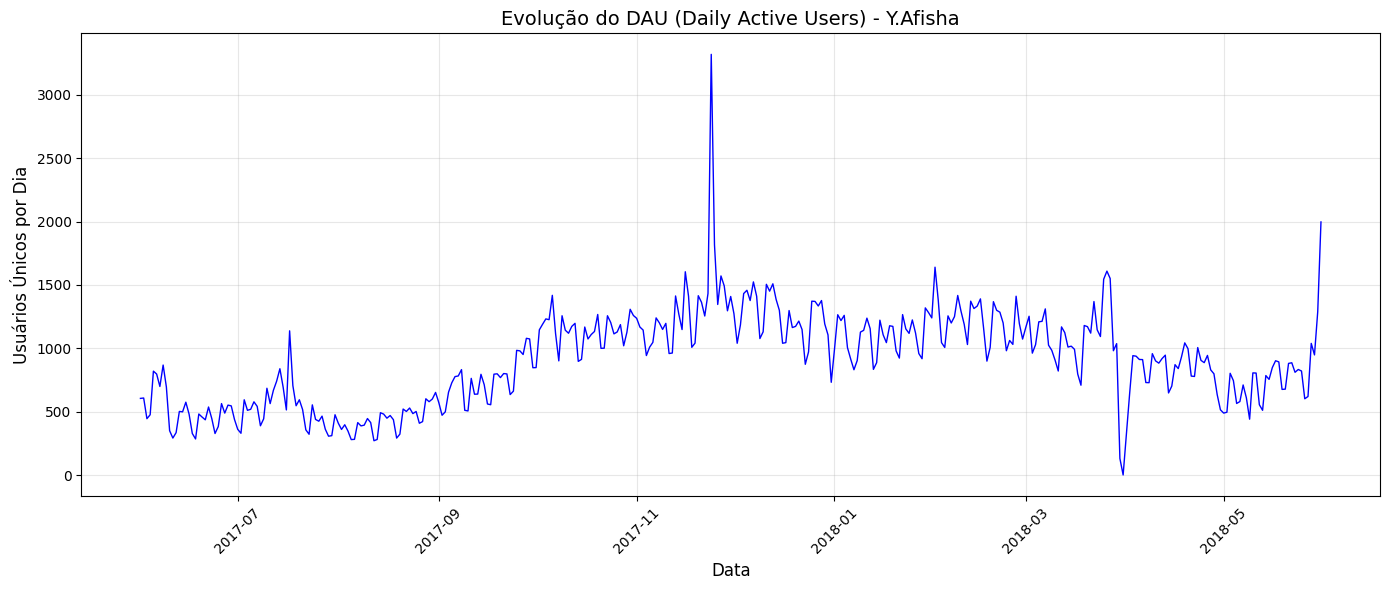

In [ ]:
# GRÁFICO 1: Evolução do DAU

plt.figure(figsize=(14, 6))
plt.plot(dau.index, dau.values, color='blue', linewidth=1)
plt.title('Evolução do DAU (Daily Active Users) - Y.Afisha', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Usuários Únicos por Dia', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.2 - Comparação: Usuários vs Sessões por dia

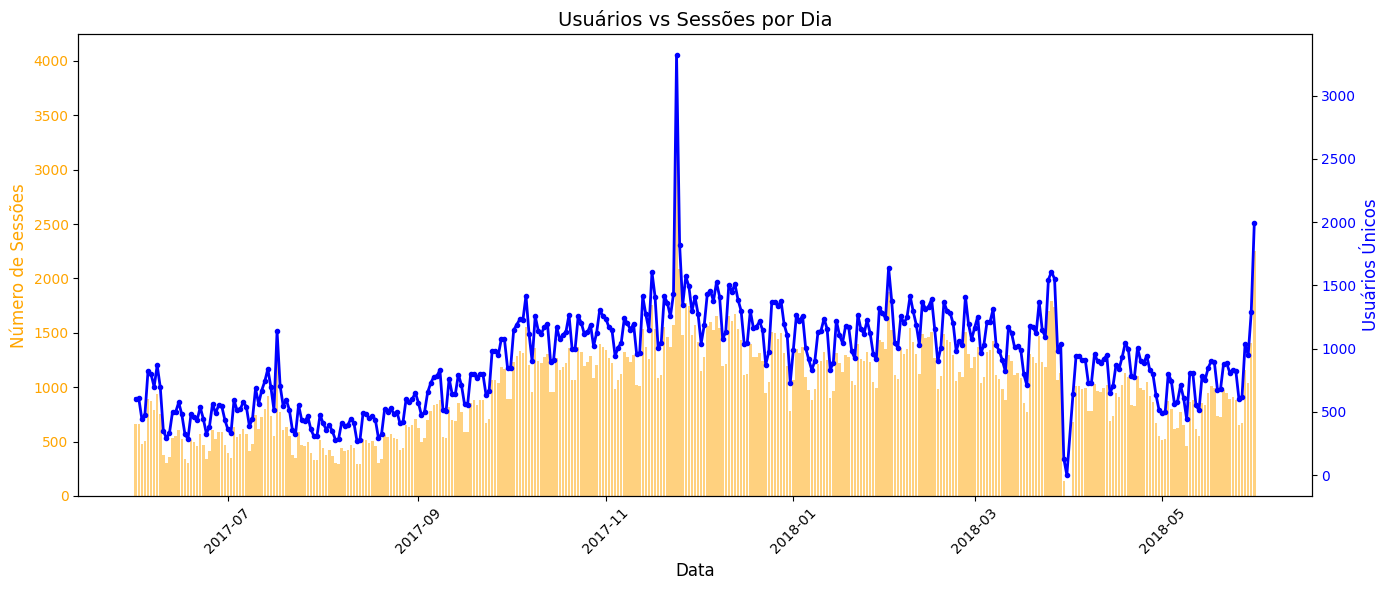

In [ ]:
# GRÁFICO 2: Usuários vs Sessões por dia
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: sessões por dia
ax1.bar(sessoes_por_dia.index, sessoes_por_dia.values, alpha=0.5, color='orange', label='Sessões')
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Número de Sessões', color='orange', fontsize=12)
ax1.tick_params(axis='y', labelcolor='orange')
ax1.tick_params(axis='x', rotation=45)

# Linha: usuários por dia
ax2 = ax1.twinx()
ax2.plot(dau.index, dau.values, color='blue', linewidth=2, marker='o', markersize=3, label='Usuários')
ax2.set_ylabel('Usuários Únicos', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Usuários vs Sessões por Dia', fontsize=14)
fig.tight_layout()
plt.show()

### 5.3 - Distribuição da duração das sessões

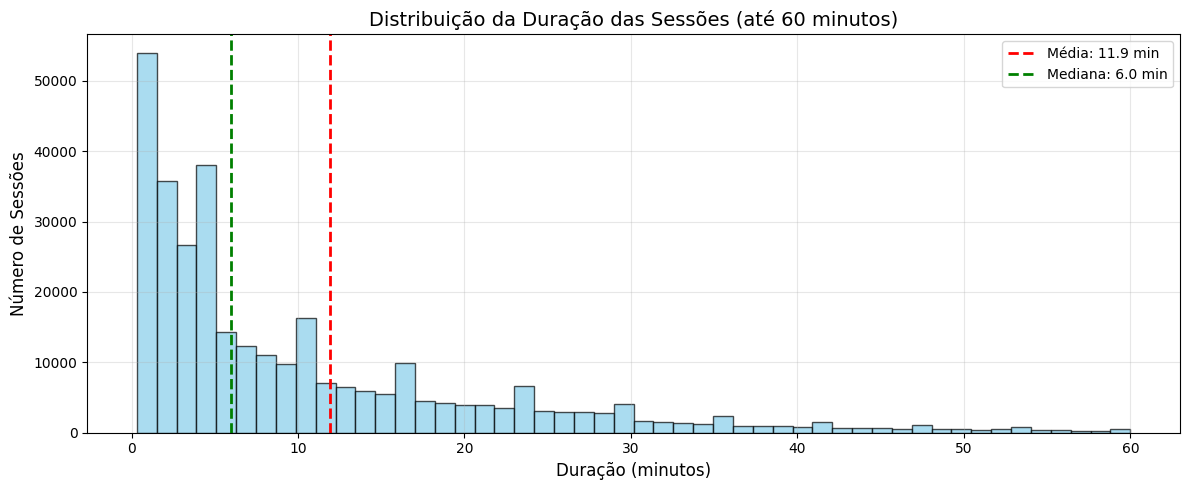

In [ ]:
# GRÁFICO 3: Distribuição da duração das sessões

plt.figure(figsize=(12, 5))

# Histograma (limitado a 60 minutos para melhor visualização)
dados_plot = df_visits_clean[df_visits_clean['duracao_min'] <= 60]

plt.hist(dados_plot['duracao_min'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df_visits_clean['duracao_min'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {df_visits_clean["duracao_min"].mean():.1f} min')
plt.axvline(df_visits_clean['duracao_min'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df_visits_clean["duracao_min"].median():.1f} min')

plt.title('Distribuição da Duração das Sessões (até 60 minutos)', fontsize=14)
plt.xlabel('Duração (minutos)', fontsize=12)
plt.ylabel('Número de Sessões', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 - Duração por dispositivo (boxplot)

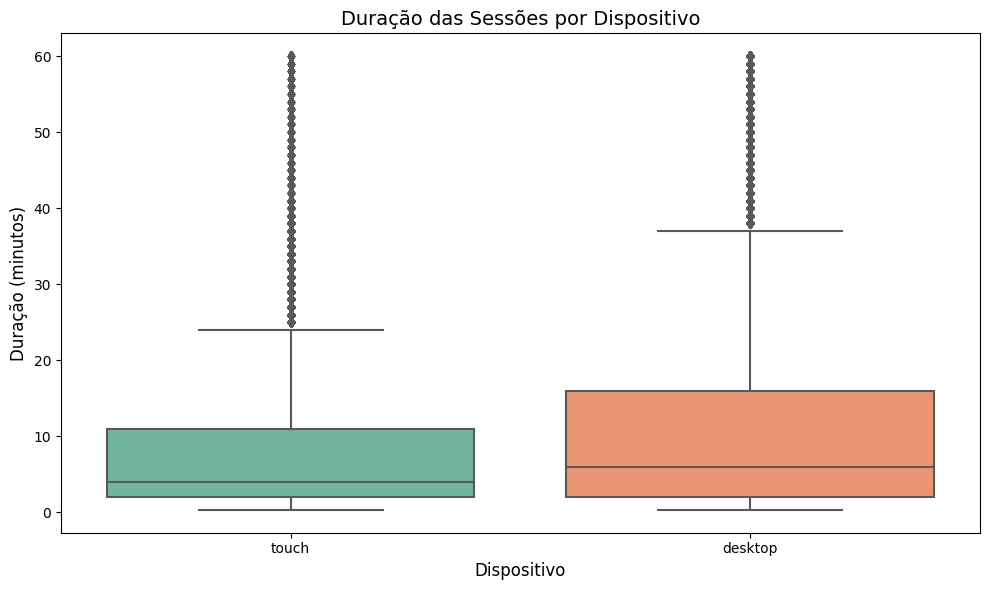

In [ ]:
# GRÁFICO 4: Duração das sessões por dispositivo

plt.figure(figsize=(10, 6))

# Filtrar outliers para melhor visualização (até 60 minutos)
dados_boxplot = df_visits_clean[df_visits_clean['duracao_min'] <= 60]

sns.boxplot(data=dados_boxplot, x='device', y='duracao_min', palette='Set2')
plt.title('Duração das Sessões por Dispositivo', fontsize=14)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Duração (minutos)', fontsize=12)
plt.tight_layout()
plt.show()

## 📊 GRÁFICOS PARA ANÁLISE DE MARKETING

### 5.5 - Gasto por origem (Top 10)

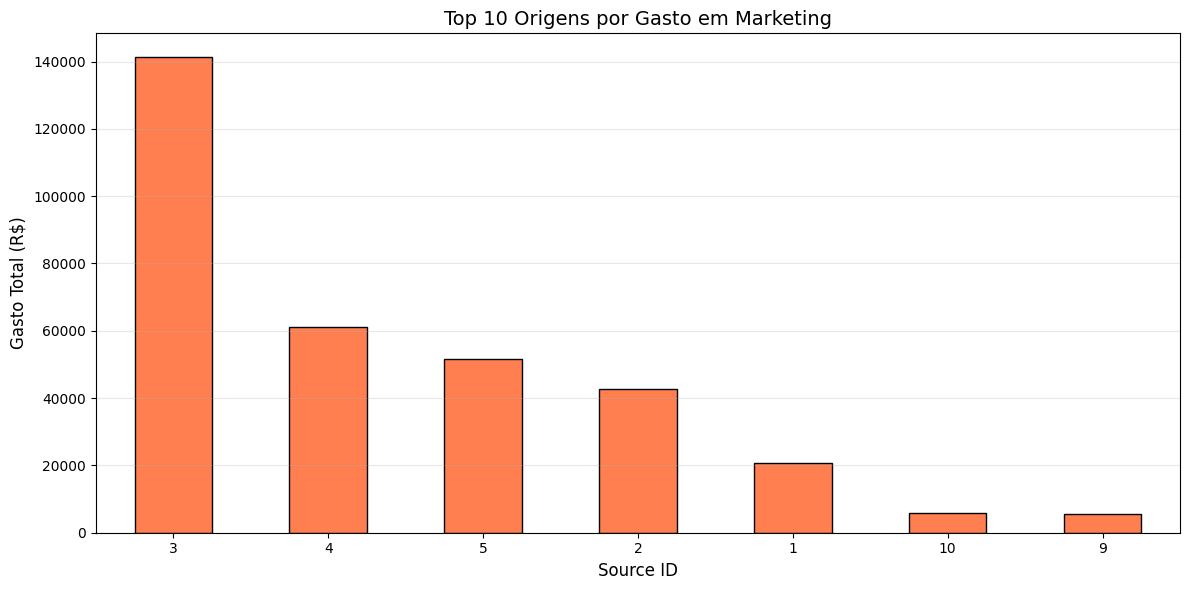

In [ ]:
# GRÁFICO 5: Gasto por origem (Top 10)

plt.figure(figsize=(12, 6))
gasto_por_origem.head(10).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Origens por Gasto em Marketing', fontsize=14)
plt.xlabel('Source ID', fontsize=12)
plt.ylabel('Gasto Total (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.6 - Evolução dos gastos ao longo do tempo

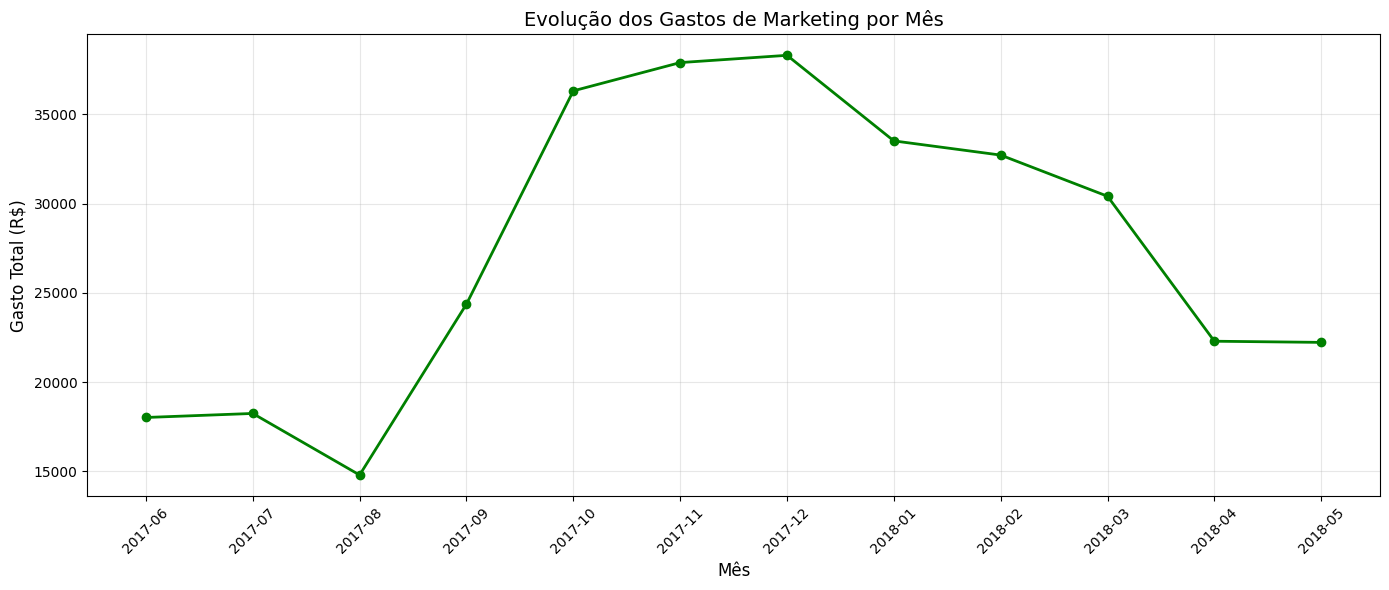

In [ ]:
# GRÁFICO 6: Evolução dos gastos de marketing

plt.figure(figsize=(14, 6))
plt.plot(gasto_por_mes.index, gasto_por_mes.values, marker='o', linewidth=2, color='green')
plt.title('Evolução dos Gastos de Marketing por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Gasto Total (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 - CAC por origem (Top 10 menores)

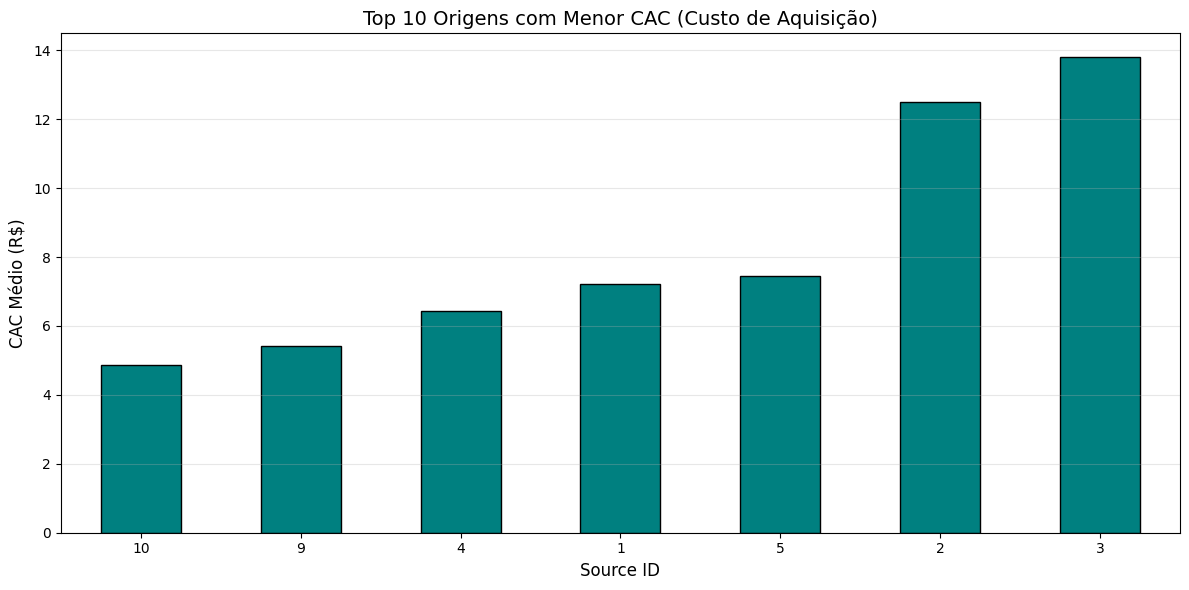

In [ ]:
# GRÁFICO 7: CAC por origem (menores custos)

plt.figure(figsize=(12, 6))
cac_medio_por_origem.head(10).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Origens com Menor CAC (Custo de Aquisição)', fontsize=14)
plt.xlabel('Source ID', fontsize=12)
plt.ylabel('CAC Médio (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.8 - Evolução do CAC por mês e fonte

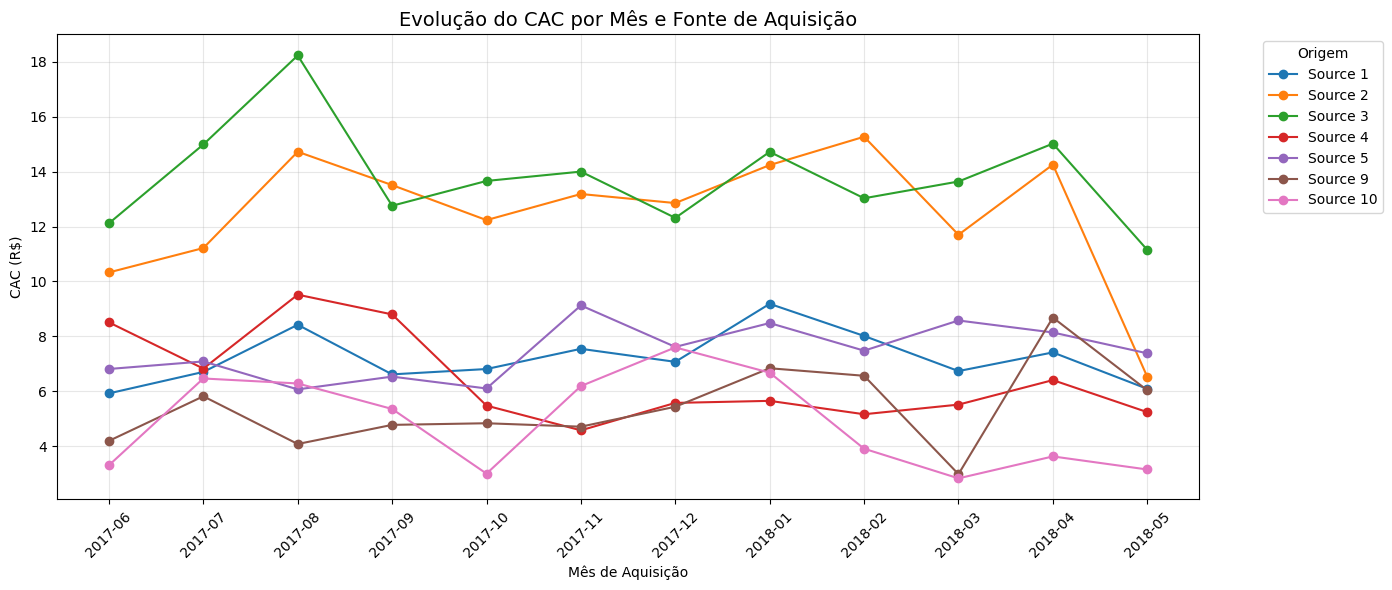

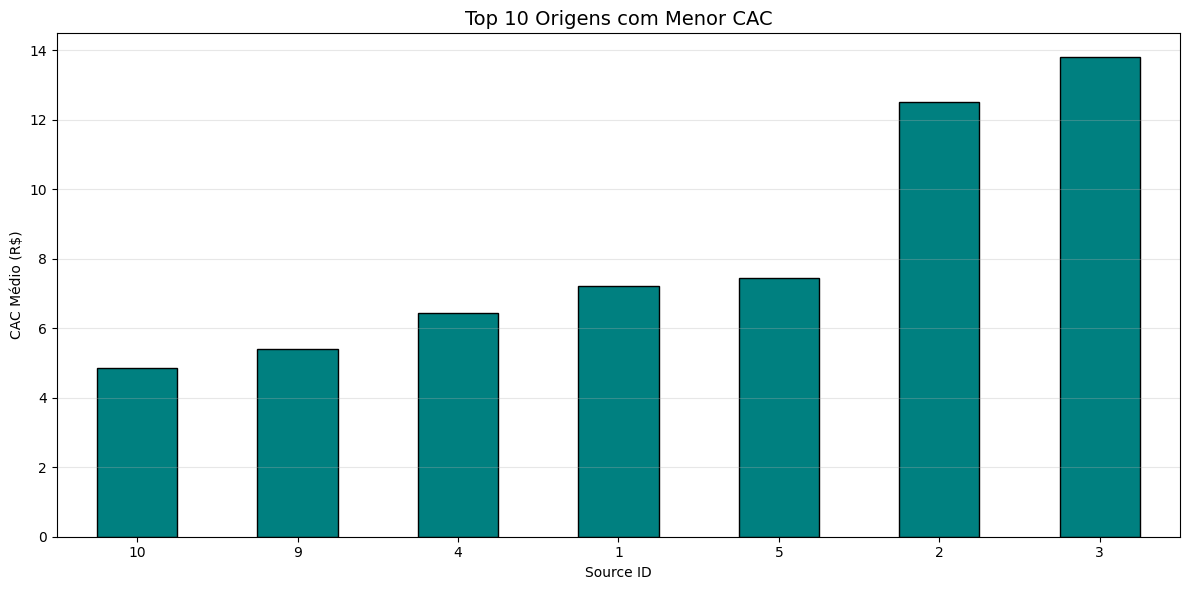

In [ ]:
# Gráfico 8: Evolução do CAC por mês e fonte
plt.figure(figsize=(14, 6))
for column in cac_pivot.columns:
    if cac_pivot[column].sum() > 0:
        plt.plot(cac_pivot.index.astype(str), cac_pivot[column], marker='o', label=f'Source {column}')

plt.title('Evolução do CAC por Mês e Fonte de Aquisição', fontsize=14)
plt.xlabel('Mês de Aquisição')
plt.ylabel('CAC (R$)')
plt.xticks(rotation=45)
plt.legend(title='Origem', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Top 10 origens com menor CAC
cac_medio_por_origem = cac_monthly_data.groupby('source_id')['cac'].mean().sort_values()

plt.figure(figsize=(12, 6))
cac_medio_por_origem.head(10).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Origens com Menor CAC', fontsize=14)
plt.xlabel('Source ID')
plt.ylabel('CAC Médio (R$)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5. 9 - ROI por origem (Top 10 e Bottom 10)

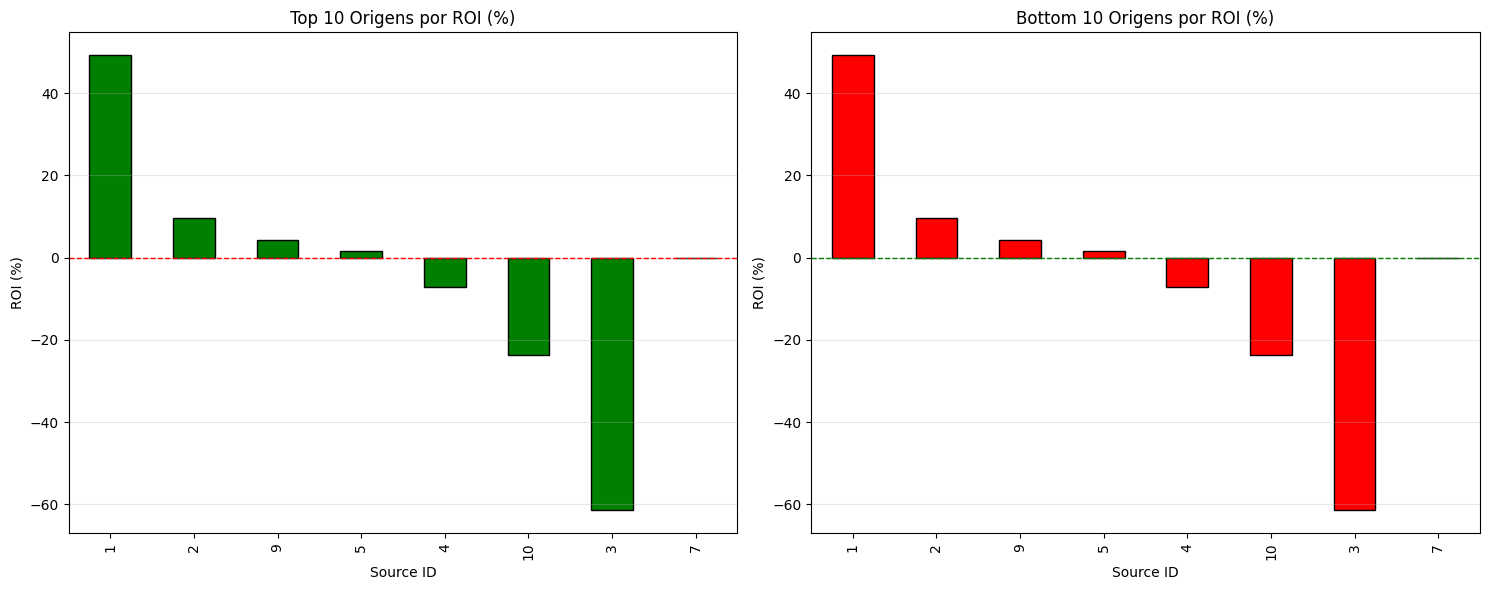

In [ ]:
# GRÁFICO 8: ROI por origem

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 ROI
roi_por_origem.head(10).plot(kind='bar', ax=axes[0], color='green', edgecolor='black')
axes[0].set_title('Top 10 Origens por ROI (%)', fontsize=12)
axes[0].set_xlabel('Source ID')
axes[0].set_ylabel('ROI (%)')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='y')

# Bottom 10 ROI (piores)
roi_por_origem.tail(10).plot(kind='bar', ax=axes[1], color='red', edgecolor='black')
axes[1].set_title('Bottom 10 Origens por ROI (%)', fontsize=12)
axes[1].set_xlabel('Source ID')
axes[1].set_ylabel('ROI (%)')
axes[1].axhline(y=0, color='green', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.10 - Mapa de calor do ROMI por coorte

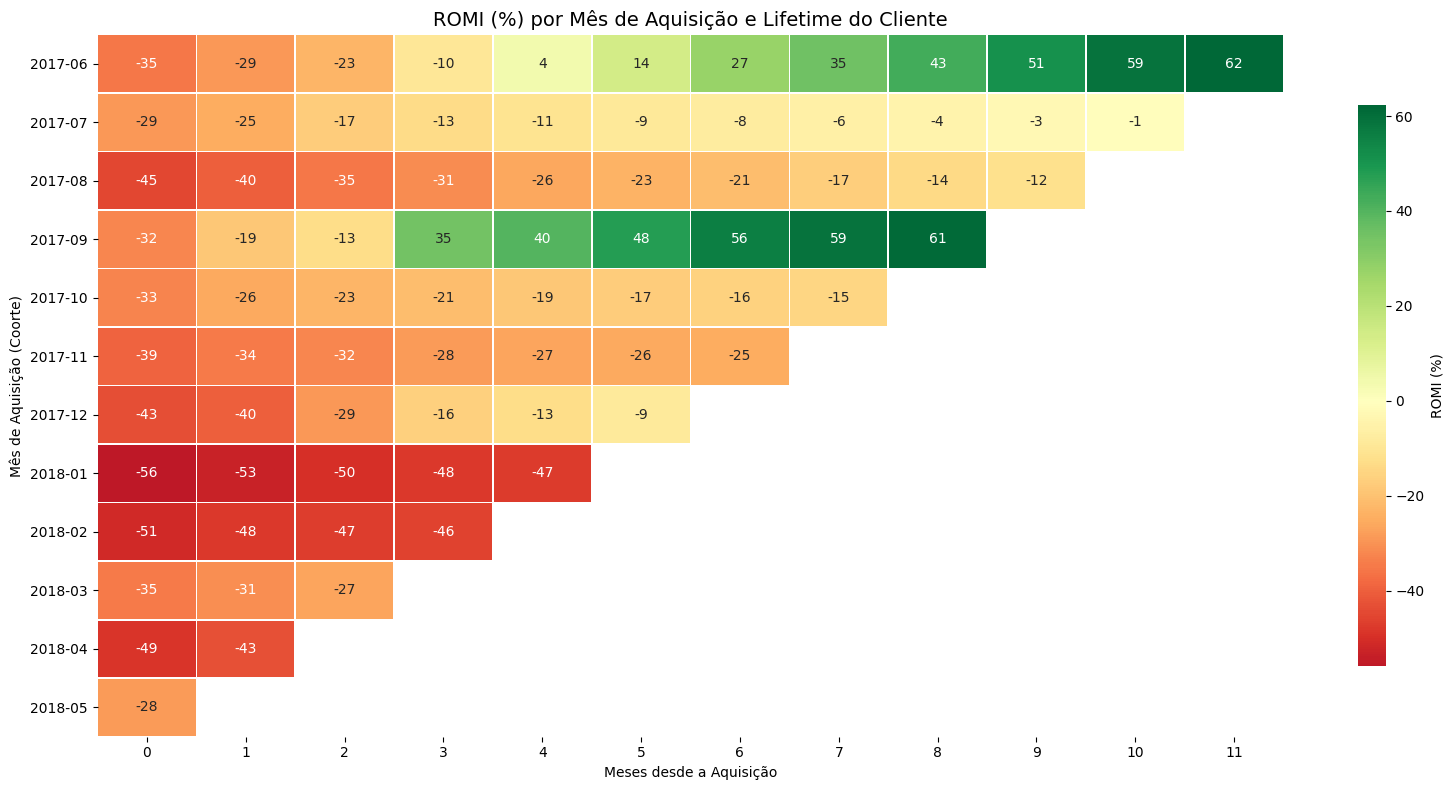

In [ ]:
# Mapa de calor do ROMI por coorte
plt.figure(figsize=(16, 8))
sns.heatmap(romi_pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            linewidths=.5, cbar_kws={"shrink": 0.8, "label": "ROMI (%)"})
plt.title('ROMI (%) por Mês de Aquisição e Lifetime do Cliente', fontsize=14)
plt.xlabel('Meses desde a Aquisição')
plt.ylabel('Mês de Aquisição (Coorte)')
plt.tight_layout()
plt.show()

### 5.11 - Ticket médio por mês

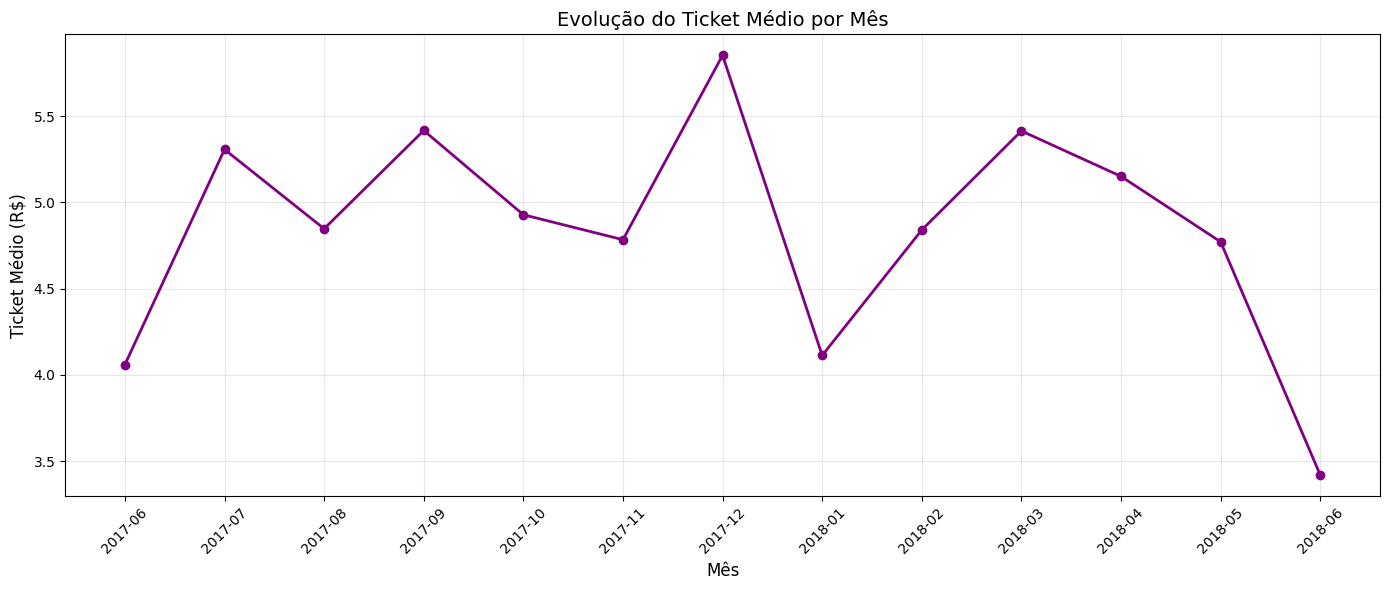

In [ ]:
# GRÁFICO 9: Evolução do Ticket Médio

plt.figure(figsize=(14, 6))
plt.plot(ticket_por_mes.index, ticket_por_mes.values, marker='o', linewidth=2, color='purple')
plt.title('Evolução do Ticket Médio por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Ticket Médio (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.12 - LTV por coorte

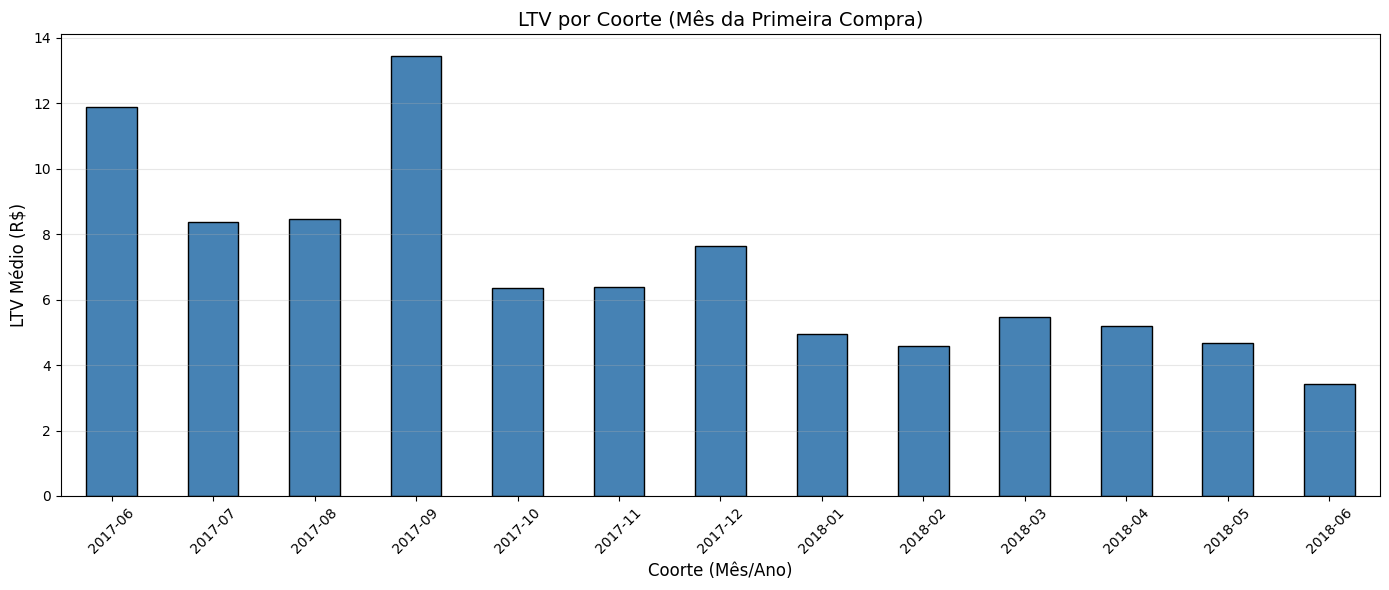

In [ ]:
# GRÁFICO 10: LTV por coorte (mês da primeira compra)

plt.figure(figsize=(14, 6))
ltv_por_coorte.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('LTV por Coorte (Mês da Primeira Compra)', fontsize=14)
plt.xlabel('Coorte (Mês/Ano)', fontsize=12)
plt.ylabel('LTV Médio (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.13 - Conclusões

- Os gráficos confirmam visualmente a superioridade do **Desktop** em termos de conversão e receita média.
- A evolução temporal do **DAU** mostra picos de acesso que nem sempre se traduzem em aumento proporcional de vendas, sugerindo que certas campanhas trazem volume, mas não necessariamente qualidade.
- As visualizações por coorte de **LTV** deixam claro que os primeiros meses de vida do cliente são os mais rentáveis, sendo crucial recuperar o investimento (CAC) logo na primeira transação.

## **✅ FASE 6 - Conclusões e Recomendações**

In [ ]:
# =================================================================
# RELATÓRIO EXECUTIVO FINAL: PERFORMANCE DE MARKETING
# =================================================================

# 1. Processamento dos dados (Lógica idêntica à anterior)
primeira_visita = df_visits.sort_values(by='start_ts').groupby('uid').agg({'source_id': 'first'}).reset_index()
pedidos_com_origem = df_orders.merge(primeira_visita, on='uid', how='left')
receita_por_origem = pedidos_com_origem.groupby('source_id').agg({'revenue': 'sum', 'uid': 'nunique'})
receita_por_origem.columns = ['Receita Total (R$)', 'Total de Clientes']
custos_por_origem = df_costs.groupby('source_id').agg({'costs': 'sum'})

# 2. Consolidação do DataFrame de Resumo
resumo_final = receita_por_origem.join(custos_por_origem, how='inner')
resumo_final.rename(columns={'costs': 'Investimento (R$)'}, inplace=True)

# 3. Cálculos de Performance
resumo_final['CAC (R$)'] = resumo_final['Investimento (R$)'] / resumo_final['Total de Clientes']
resumo_final['ROMI (%)'] = (resumo_final['Receita Total (R$)'] / resumo_final['Investimento (R$)']) * 100

# 4. Formatação Visual Profissional (Estilização)
def destacar_romi(val):
    color = 'green' if val > 100 else 'red'
    return f'color: {color}; font-weight: bold'

df_estilizado = resumo_final.sort_values(by='ROMI (%)', ascending=False).style\
    .format({'Receita Total (R$)': '{:,.2f}',
             'Investimento (R$)': '{:,.2f}',
             'CAC (R$)': '{:,.2f}',
             'ROMI (%)': '{:.2f}%'})\
    .applymap(destacar_romi, subset=['ROMI (%)'])\
    .background_gradient(cmap='Greens', subset=['Receita Total (R$)'])\
    .set_caption("RESUMO EXECUTIVO: DESEMPENHO POR ORIGEM DE ANÚNCIO")\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#4b6584'), ('color', 'white')]}])

# Exibição
display(df_estilizado)

# Tabela secundária: Ticket Médio por Dispositivo
print("\n" + "="*50)
print("ANÁLISE DE TICKET MÉDIO POR DISPOSITIVO")
print("="*50)
pedidos_dispositivo = df_orders.merge(df_visits[['uid', 'device']].drop_duplicates('uid'), on='uid', how='left')
display(pedidos_dispositivo.groupby('device')['revenue'].mean().to_frame('Ticket Médio (R$)').round(2))

,Receita Total (R$),Total de Clientes,Investimento (R$),CAC (R$),ROMI (%)
source_id,,,,,
1,"31,090.55",2899,"20,833.27",7.19,149.24%
2,"46,923.61",3506,"42,806.04",12.21,109.62%
9,"5,759.40",1088,"5,517.49",5.07,104.38%
5,"52,624.02",6931,"51,757.10",7.47,101.67%
4,"56,696.83",10296,"61,073.60",5.93,92.83%
10,"4,450.33",1329,"5,822.49",4.38,76.43%
3,"54,511.24",10473,"141,321.63",13.49,38.57%



ANÁLISE DE TICKET MÉDIO POR DISPOSITIVO


,Ticket Médio (R$)
device,
desktop,5.17
touch,4.26


### 1. Conclusão Geral sobre o Produto e Vendas

- **Retenção Crítica:** Apenas **22,8%** dos usuários retornam ao site após a primeira visita, e **72,2%** das compras ocorrem no primeiro dia (conversão D0). Isso indica um comportamento de compra imediata, mas muito baixa recorrência.

- **Ticket Médio Baixo:** O ticket médio geral é de **R$ 5,00**, com tendência de queda ao longo de 2018, sugerindo que a empresa pode estar vendendo produtos mais baratos ou concedendo mais descontos.

- **Desktop vs. Touch:** Usuários de **Desktop** são mais valiosos: maior ticket médio (R$ 5,17 vs. R$ 4,26), maior tempo de sessão e maior LTV.

### 2. Diagnóstico de Marketing (Alocação Ineficiente)

- **Canais Rentáveis (ROI positivo):** Origens **1, 2, 5 e 9**. A Origem 1 é a melhor (ROI 49,24%, CAC R$ 7,19).

- **Canais Problemáticos (ROI negativo):** Origens **3 (ROI -61,43%)** e **4 (ROI -7,17%)**. Juntas, receberam **R$ 202.395,23** em investimento (62% do total) e geraram prejuízo.

- **Origem 3** é o maior vilão: 43% do orçamento, maior CAC, pior ROI. Este canal precisa ser drasticamente reduzido ou eliminado.

### 3. Recomendações Estratégicas

#### 3.1. Redistribuição Imediata do Orçamento (Prioridade Máxima)
- **Suspender ou reduzir drasticamente** os investimentos na **Origem 3** e reavaliar a **Origem 4**. O dinheiro aplicado nesses canais tem retorno negativo – a empresa está perdendo capital a cada cliente adquirido.
- **Realocar o orçamento** para as **Origens 1, 2, 5 e 9**, que comprovadamente geram ROI positivo e sustentável.

#### 3.2. Estratégias para Aumentar Retenção e LTV
- Implementar **programas de email marketing, remarketing e SMS** direcionados aos clientes que compraram no primeiro dia (72% da base). Ofertas personalizadas e descontos para segunda compra podem aumentar significativamente o LTV.
- O mapa de calor do ROMI mostra que o retorno máximo é no mês 0. Por isso, ações de **upsell e cross-sell** devem ocorrer imediatamente após a primeira compra – antes que o cliente se torne inativo.

#### 3.3. Otimização por Dispositivo
- Manter e **ampliar os investimentos em campanhas direcionadas para Desktop**, onde o ROI historicamente é superior.
- Realizar uma **auditoria de UX/UI no fluxo de compra para dispositivos móveis (Touch)**. Identificar gargalos que possam explicar o ticket médio 17% menor em comparação ao Desktop.

#### 3.4. Gestão de Preços e Promoções
- A tendência de queda no ticket médio ao longo de 2018 deve ser investigada. Recomenda-se evitar **promoções agressivas ou descontos excessivos** que erodem a rentabilidade, a menos que sejam estrategicamente direcionados para clientes de alto LTV.

#### 3.5. Sazonalidade e Picos de Demanda
- Aproveitar os picos de conversão observados no **final do ano** (coortes de novembro/dezembro com maior LTV) para intensificar campanhas nas Origens de melhor desempenho (1, 2, 5 e 9), maximizando o ROI nos períodos de maior disposição de gasto do consumidor.